##***Importing Grid-world Environment***

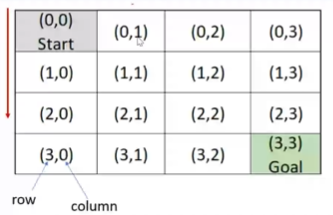

In [ ]:
# YASH KHAMKAR - 221A030
import numpy as np
import random

# Grid-world environment
class GridWorld:
    def __init__(self, size = 4, start = (0,0), goal = (3,3)):
        self.size = size
        self.start = start
        self.goal = goal
        self.state = start
        self.actions = [(0,1), (1,0), (0,-1), (-1,0)]
        self.action_names = ["right", "down", "left", "up"]

    def reset(self):
      self.state = self.start
      return self.state

    def step(self, action):
      next_state = (self.state[0] + self.actions[action][0],
                    self.state[1] + self.actions[action][1])

      if 0 <= next_state[0] < self.size and 0 <= next_state[1] < self.size:
        self.state = next_state

      reward = 1 if self.state == self.goal else -0.1
      done = self.state == self.goal
      return self.state, reward, done

##***Monte Carlo Control with Exploring starts***


---

This is a model free reinforcement learning algorithm that learns by sampling episodes and averaging rewards.

In [ ]:
# YASH KHAMKAR - 221A030
def monte_carlo_control(env, episodes=5000, gamma=0.9, epsilon=0.1):
  Q = {((i, j), a): 0 for i in range(env.size) for j in range(env.size) for a in range(4)}
  returns = {((i, j), a): [] for i in range(env.size) for j in range(env.size) for a in range(4)}

  for episode in range(episodes):
    state = env.reset()
    episode = []

    while True:
      action = random.choice(range(4)) if random.random() < epsilon else max(range(4), key=lambda a: Q[(state,a)])
      next_state, reward, done = env.step(action)
      episode.append((state, action, reward))
      state = next_state
      if done:
        break

      G = 0
      for state, action, reward in reversed(episode):
        G = gamma * G + reward
        if (state, action) not in [(s, a) for s, a, episode in episode[:-1]]:
          returns[(state, action)].append(G)
          Q[(state, action)] = np.mean(returns[(state, action)])

    return Q

##***SARSA (STATE ACTION REWARD STATE ACTION)***


---
This is a Temporal Difference Learning Algorithm


In [ ]:
# YASH KHAMKAR - 221A030
# Temporal Difference Learning SARSA
def sarsa(env, episodes=5000, gamma=0.9, epsilon=0.1, alpha=0.1):
  Q = {((i, j), a): 0 for i in range(env.size) for j in range(env.size) for a in range(4)}

  for episode in range(episodes):
    state = env.reset()
    action = random.choice(range(4)) if random.random() < epsilon else max(range(4), key=lambda a: Q[(state,a)])

    while True:
      next_state, reward, done = env.step(action)
      next_action = random.choice(range(4)) if random.random() < epsilon else max(range(4), key=lambda a: Q[(next_state,a)])
      Q[(state, action)] += alpha * (reward + gamma * Q[(next_state, next_action)] - Q[(state, action)])
      state, action = next_state, next_action
      if done:
        break

  return Q

##***Q learning Algorithm***

In [ ]:
# YASH KHAMKAR - 221A030
# Q-Learning Algorithm
def q_learning(env, episodes=5000, gamma=0.9, epsilon=0.1, alpha=0.1):
  Q = {((i, j), a): 0 for i in range(env.size) for j in range(env.size) for a in range(4)}

  for episode in range(episodes):
    state = env.reset()

    while True:
      action = random.choice(range(4)) if random.random() < epsilon else max(range(4), key=lambda a: Q[(state,a)])
      next_state, reward, done = env.step(action)

      # Q-learning update: Use max Q-value of next_state, not a chosen next_action
      max_next_q = max(Q[(next_state, a)] for a in range(4))
      Q[(state, action)] += alpha * (reward + gamma * max_next_q - Q[(state, action)])
      state = next_state # In Q-learning, the action for the next state is not part of the update for the current state
      if done:
        break

  return Q

##***Training the data with various learning***

In [ ]:
# YASH KHAMKAR - 221A030
# Initialise Environment
env = GridWorld()

# Train with Monte carlo
Q_mc = monte_carlo_control(env)

# Train with SARSA
Q_sarsa = sarsa(env)

# Train with Q-Learning
Q_qlearning = q_learning(env)

##***Sample Q values***

In [ ]:
# YASH KHAMKAR - 221A030
# Print Sample Q values
print("Sample Q-values from Monte Carlo:", list(Q_mc.items())[:20])
print("Sample Q-values from SARSA:", list(Q_sarsa.items())[:20])
print("Sample Q-values from Q-Learning:", list(Q_qlearning.items())[:20])

Sample Q-values from Monte Carlo: [(((0, 0), 0), np.float64(-0.1)), (((0, 0), 1), np.float64(-0.1)), (((0, 0), 2), np.float64(-0.1)), (((0, 0), 3), np.float64(-0.1)), (((0, 1), 0), 0), (((0, 1), 1), 0), (((0, 1), 2), 0), (((0, 1), 3), 0), (((0, 2), 0), 0), (((0, 2), 1), 0), (((0, 2), 2), 0), (((0, 2), 3), 0), (((0, 3), 0), 0), (((0, 3), 1), 0), (((0, 3), 2), 0), (((0, 3), 3), 0), (((1, 0), 0), 0), (((1, 0), 1), 0), (((1, 0), 2), 0), (((1, 0), 3), 0)]
Sample Q-values from SARSA: [(((0, 0), 0), 0.08943896006277316), (((0, 0), 1), 0.11276459847464065), (((0, 0), 2), -0.006723624523780836), (((0, 0), 3), -0.0014458625898461103), (((0, 1), 0), 0.22295732002707577), (((0, 1), 1), 0.23924724112681564), (((0, 1), 2), -0.024748815929450562), (((0, 1), 3), 0.10992543660270607), (((0, 2), 0), 0.3262183730444011), (((0, 2), 1), 0.4151123345145738), (((0, 2), 2), 0.06878082521483324), (((0, 2), 3), 0.2054974624288393), (((0, 3), 0), -0.004125745327073119), (((0, 3), 1), 0.5715748011885398), (((0, 3